## Import Library

In [1]:
import os
import platform

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import lightgbm as lgb
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print(f"python : {platform.python_version()}")
print(f"numpy : {np.__version__}")
print(f"pandas : {pd.__version__}")
print(f"tensorflow : {tf.__version__}")
print(f"keras : {keras.__version__}")
print(f"lightgbm : {lgb.__version__}")
print(f"xgboost : {xgb.__version__}")
print(f"GPU tersedia : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"random seed : {SEED}")

python : 3.12.13
numpy : 2.0.2
pandas : 2.3.3
tensorflow : 2.20.0
keras : 3.13.2
lightgbm : 4.6.0
xgboost : 3.2.0
GPU tersedia : True
random seed : 42


## Load Fitur & Split Data dari NB2

In [2]:
FEATURES_PATH = "/kaggle/input/notebooks/kkndesalalatedzong/notebook02/features_gold.csv"
SPLIT_PATH = "/kaggle/input/notebooks/kkndesalalatedzong/notebook02/split_assignment.csv"

features = pd.read_csv(FEATURES_PATH)
split = pd.read_csv(SPLIT_PATH)

print(f"Baris features_gold : {len(features)} ({features['path'].nunique()} eksekusi)")
print(f"Checkpoint di data   : {sorted(features['window_s'].unique())}")
print(f"Distribusi split     : {split['split'].value_counts().to_dict()}")

train_paths = split.loc[split.split == "train", "path"]
val_paths = split.loc[split.split == "val", "path"]

Baris features_gold : 59070 (1969 eksekusi)
Checkpoint di data   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Distribusi split     : {'train': 1007, 'external': 530, 'val': 216, 'test': 216}


## Konfigurasi

In [3]:
STEP_VALUES = [1, 2, 3, 5, 10]

STORAGE_FEATURE_NAMES = ["T_s_r", "T_s_w", "V_s_r", "V_s_w", "H_s_w"]
MEMORY_FEATURE_NAMES = (
    ["H_m_w", "H_m_rw"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
ALL_FEATURE_NAMES = STORAGE_FEATURE_NAMES + MEMORY_FEATURE_NAMES
FEATURE_COLUMNS_FULL = ALL_FEATURE_NAMES + ["w"]
assert len(FEATURE_COLUMNS_FULL) == 24


def checkpoints_for_step(step, max_w=30):
    return list(range(step, max_w + 1, step))


for step in STEP_VALUES:
    grid = checkpoints_for_step(step)
    print(f"step={step:>2} detik -> {len(grid):>2} checkpoint: {grid}")

total_dl_trainings = len(STEP_VALUES) * 3
total_classical_models = sum(len(checkpoints_for_step(s)) for s in STEP_VALUES) * 3
print(f"\nTotal pelatihan DL     : {total_dl_trainings} (5 step x 3 arsitektur)")
print(f"Total model klasik     : {total_classical_models} (Decision Tree + LightGBM + XGBoost, seluruh step)")


step= 1 detik -> 30 checkpoint: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
step= 2 detik -> 15 checkpoint: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
step= 3 detik -> 10 checkpoint: [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]
step= 5 detik ->  6 checkpoint: [5, 10, 15, 20, 25, 30]
step=10 detik ->  3 checkpoint: [10, 20, 30]

Total pelatihan DL     : 15 (5 step x 3 arsitektur)
Total model klasik     : 192 (Decision Tree + LightGBM + XGBoost, seluruh step)


## Fungsi Sequence & Pre-Processing 

In [4]:
LOG1P_FEATURES = (
    ["T_s_r", "T_s_w", "V_s_r", "V_s_w"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
LOG1P_IDX = [FEATURE_COLUMNS_FULL.index(f) for f in LOG1P_FEATURES]
assert len(LOG1P_FEATURES) == 20


def build_sequences(df, paths, checkpoint_grid, feature_names):
    sub = df[df["path"].isin(paths) & df["window_s"].isin(checkpoint_grid)]
    sequences, labels = [], []
    for path, g in sub.groupby("path", sort=False):
        g = g.sort_values("window_s")
        assert len(g) == len(checkpoint_grid), (
            f"Eksekusi {path} punya {len(g)} baris, diharapkan {len(checkpoint_grid)} checkpoint."
        )
        w = g["window_s"].to_numpy(dtype="float64")
        feat = g[feature_names].to_numpy(dtype="float64")
        sequences.append(np.concatenate([feat, w[:, None]], axis=1))
        labels.append(int(g["is_ransomware"].iloc[0]))
    X = np.stack(sequences).astype("float32")
    y = np.array(labels, dtype="int32")
    return X, y


def apply_log1p(X, idx):
    X = X.copy()
    X[..., idx] = np.log1p(np.clip(X[..., idx], a_min=0.0, a_max=None))
    return X


def scale_3d(X, scaler):
    shp = X.shape
    return scaler.transform(X.reshape(-1, shp[-1])).reshape(shp).astype("float32")


## Define Deep Learning (Backbone Kausal + Multi-Exit)

In [5]:
def build_cnn_lstm(seq_len, n_features):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = layers.Conv1D(filters=32, kernel_size=3, padding="causal", activation="linear")(inputs)
    x = layers.LSTM(256, return_sequences=True)(x)
    x = layers.LSTM(256, return_sequences=True)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="cnn_lstm_modified")


def build_gru(seq_len, n_features, units=64):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = layers.GRU(units, return_sequences=True)(inputs)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="gru")


def _tcn_residual_block(x, filters, kernel_size, dilation_rate):
    prev = x
    h = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(x)
    h = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(h)
    if prev.shape[-1] != filters:
        prev = layers.Conv1D(filters, 1, padding="same")(prev)
    return layers.Add()([prev, h])


def build_tcn(seq_len, n_features, filters=32, dilations=(1, 2, 4)):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = inputs
    for d in dilations:
        x = _tcn_residual_block(x, filters, kernel_size=3, dilation_rate=d)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="tcn")


def train_dl_model(build_fn, name, X_train, y_train_seq, X_val, y_val_seq, epochs=50, batch_size=32):
    keras.utils.set_random_seed(SEED)
    model = build_fn(X_train.shape[1], X_train.shape[2])
    model.compile(optimizer="adam", loss="binary_crossentropy")
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    history = model.fit(
        X_train, y_train_seq, validation_data=(X_val, y_val_seq),
        epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=0,
    )
    print(f"  [{name}] {len(history.history['loss'])} epoch, "
          f"val_loss akhir={history.history['val_loss'][-1]:.4f}, params={model.count_params():,}")
    return model

## Latih & Evaluasi Keenam Model

In [6]:
all_results = []
all_complexity = []

for step in STEP_VALUES:
    grid = checkpoints_for_step(step)
    print(f"\n{'=' * 70}\nSTEP = {step} detik -> {len(grid)} checkpoint: {grid}\n{'=' * 70}")

    X_train_raw, y_train = build_sequences(features, train_paths, grid, ALL_FEATURE_NAMES)
    X_val_raw, y_val = build_sequences(features, val_paths, grid, ALL_FEATURE_NAMES)

    X_train_log = apply_log1p(X_train_raw, LOG1P_IDX)
    X_val_log = apply_log1p(X_val_raw, LOG1P_IDX)
    scaler = StandardScaler().fit(X_train_log.reshape(-1, X_train_log.shape[-1]))
    X_train = scale_3d(X_train_log, scaler)
    X_val = scale_3d(X_val_log, scaler)

    y_train_seq = np.repeat(y_train[:, None, None], len(grid), axis=1).astype("float32")
    y_val_seq = np.repeat(y_val[:, None, None], len(grid), axis=1).astype("float32")

    print(f"  X_train {X_train.shape}, X_val {X_val.shape}")

    # 3 model deep learning
    dl_models = {}
    for name, build_fn in [("CNN-LSTM", build_cnn_lstm), ("GRU", build_gru), ("TCN", build_tcn)]:
        model = train_dl_model(build_fn, name, X_train, y_train_seq, X_val, y_val_seq)
        dl_models[name] = model
        all_complexity.append({"step": step, "model": name, "satuan": "parameter (NN)",
                                "ukuran_aktif": model.count_params(), "ukuran_total": model.count_params()})
        y_prob = model.predict(X_val, verbose=0)
        for i, w in enumerate(grid):
            y_pred = (y_prob[:, i, 0] > 0.5).astype(int)
            all_results.append({"step": step, "model": name, "window_s": w,
                                 "f1": f1_score(y_val, y_pred, zero_division=0)})

    # 3 keluarga model klasik, N model terpisah per checkpoint
    dtree_models, lgbm_models, xgb_models = {}, {}, {}
    for i, w in enumerate(grid):
        Xw_train = X_train[:, i, :]
        dtree_models[w] = DecisionTreeClassifier(random_state=SEED).fit(Xw_train, y_train)
        lgbm_models[w] = lgb.LGBMClassifier(random_state=SEED, verbose=-1).fit(Xw_train, y_train)
        xgb_models[w] = xgb.XGBClassifier(random_state=SEED, eval_metric="logloss").fit(Xw_train, y_train)
    print(f"  [Decision Tree] {len(grid)} model terlatih")
    print(f"  [LightGBM] {len(grid)} model terlatih")
    print(f"  [XGBoost] {len(grid)} model terlatih")

    dtree_nodes = [m.tree_.node_count for m in dtree_models.values()]
    all_complexity.append({"step": step, "model": "Decision Tree",
                            "satuan": "node pohon (per model x N model)",
                            "ukuran_aktif": int(np.mean(dtree_nodes)), "ukuran_total": int(np.sum(dtree_nodes))})
    lgbm_trees = [m.booster_.num_trees() for m in lgbm_models.values()]
    all_complexity.append({"step": step, "model": "LightGBM",
                            "satuan": "jumlah pohon (per model x N model)",
                            "ukuran_aktif": int(np.mean(lgbm_trees)), "ukuran_total": int(np.sum(lgbm_trees))})
    xgb_trees = [m.get_booster().num_boosted_rounds() for m in xgb_models.values()]
    all_complexity.append({"step": step, "model": "XGBoost",
                            "satuan": "jumlah pohon (per model x N model)",
                            "ukuran_aktif": int(np.mean(xgb_trees)), "ukuran_total": int(np.sum(xgb_trees))})

    for i, w in enumerate(grid):
        Xw_val = X_val[:, i, :]
        for name, models_dict in [("Decision Tree", dtree_models), ("LightGBM", lgbm_models), ("XGBoost", xgb_models)]:
            y_pred = models_dict[w].predict(Xw_val)
            all_results.append({"step": step, "model": name, "window_s": w,
                                 "f1": f1_score(y_val, y_pred, zero_division=0)})

results_df = pd.DataFrame(all_results)
complexity_df = pd.DataFrame(all_complexity)
results_df.to_csv("/kaggle/working/nb3_f1_step_ablation.csv", index=False)
complexity_df.to_csv("/kaggle/working/nb3_complexity_step_ablation.csv", index=False)
print(f"\n\nSelesai seluruh step. Total baris hasil F1: {len(results_df)}")



STEP = 1 detik -> 30 checkpoint: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
  X_train (1007, 30, 24), X_val (216, 30, 24)


I0000 00:00:1789777217.034291      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789777217.037415      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  [CNN-LSTM] 28 epoch, val_loss akhir=0.6164, params=823,841
  [GRU] 26 epoch, val_loss akhir=0.3675, params=17,345


I0000 00:00:1789777267.924976      73 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  [TCN] 36 epoch, val_loss akhir=0.4489, params=18,689
  [Decision Tree] 30 model terlatih
  [LightGBM] 30 model terlatih
  [XGBoost] 30 model terlatih


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  X_train (1007, 6, 24), X_val (216, 6, 24)
  [CNN-LSTM] 20 epoch, val_loss akhir=0.4014, params=823,841
  [GRU] 34 epoch, val_loss akhir=0.3281, params=17,345
  [TCN] 35 epoch, val_loss akhir=0.3563, params=18,689
  [Decision Tree] 6 model terlatih
  [LightGBM] 6 model terlatih
  [XGBoost] 6 model terlatih

STEP = 10 detik -> 3 checkpoint: [10, 20, 30]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  X_train (1007, 3, 24), X_val (216, 3, 24)
  [CNN-LSTM] 22 epoch, val_loss akhir=0.3637, params=823,841
  [GRU] 38 epoch, val_loss akhir=0.2886, params=17,345
  [TCN] 26 epoch, val_loss akhir=0.3751, params=18,689
  [Decision Tree] 3 model terlatih
  [LightGBM] 3 model terlatih
  [XGBoost] 3 model terlatih


Selesai seluruh step. Total baris hasil F1: 384


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Visualisasi F1-Checkpoint

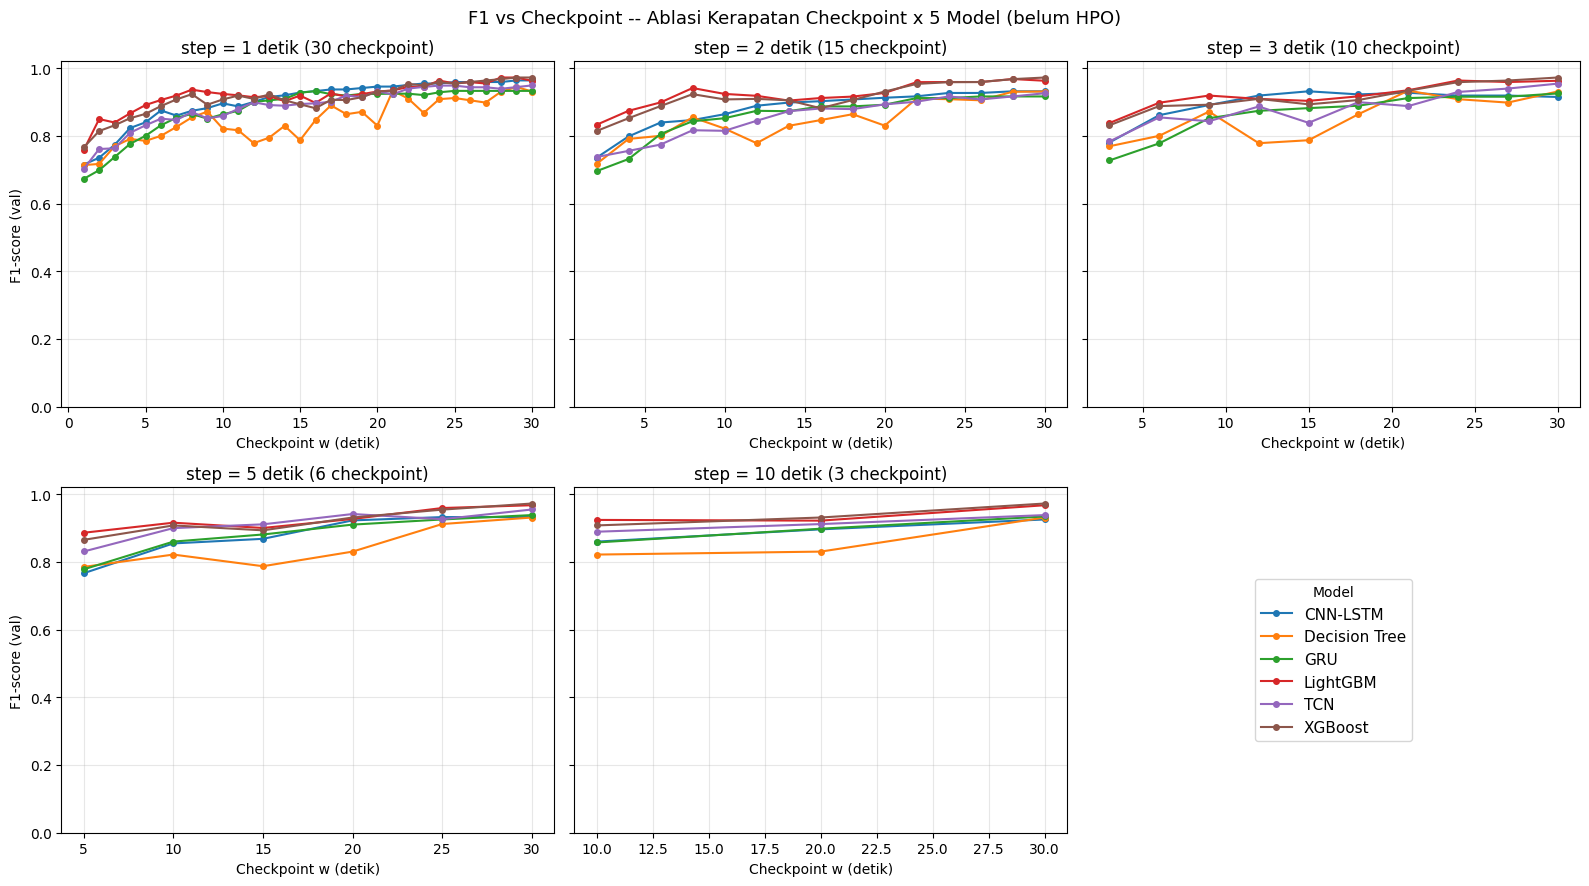

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for ax, step in zip(axes, STEP_VALUES):
    sub = results_df[results_df.step == step]
    for name, g in sub.groupby("model"):
        g = g.sort_values("window_s")
        ax.plot(g["window_s"], g["f1"], marker="o", markersize=4, label=name)
    ax.set_title(f"step = {step} detik ({len(checkpoints_for_step(step))} checkpoint)")
    ax.set_xlabel("Checkpoint w (detik)")
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("F1-score (val)")
axes[3].set_ylabel("F1-score (val)")
axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, loc="center", fontsize=11, title="Model")
fig.suptitle("F1 vs Checkpoint -- Ablasi Kerapatan Checkpoint x 5 Model (belum HPO)", fontsize=13)
plt.tight_layout()
plt.show()


## Hitung Kompleksitas Model

In [8]:
pivot_complexity = complexity_df.pivot(index="model", columns="step", values="ukuran_total")
print("=== ukuran_total per step (lihat satuan per model di kolom 'satuan') ===")
print(complexity_df.drop_duplicates("model")[["model", "satuan"]].to_string(index=False))
print()
print(pivot_complexity.to_string())

=== ukuran_total per step (lihat satuan per model di kolom 'satuan') ===
        model                             satuan
     CNN-LSTM                     parameter (NN)
          GRU                     parameter (NN)
          TCN                     parameter (NN)
Decision Tree   node pohon (per model x N model)
     LightGBM jumlah pohon (per model x N model)
      XGBoost jumlah pohon (per model x N model)

step               1       2       3       5       10
model                                                
CNN-LSTM       823841  823841  823841  823841  823841
Decision Tree    4920    2371    1584     934     409
GRU             17345   17345   17345   17345   17345
LightGBM         3000    1500    1000     600     300
TCN             18689   18689   18689   18689   18689
XGBoost          3000    1500    1000     600     300


## Ongkos Resolusi Lebih Kasar (Dibanding step=1 pada Checkpoint yang Sama)

In [9]:
baseline = results_df[results_df.step == 1][["model", "window_s", "f1"]].rename(columns={"f1": "f1_step1"})
merged = results_df[results_df.step > 1].merge(baseline, on=["model", "window_s"], how="left")
merged["degradasi_f1"] = merged["f1_step1"] - merged["f1"]

summary = merged.groupby(["step", "model"])["degradasi_f1"].mean().reset_index()
print("=== Rata-rata degradasi F1 dibanding step=1, pada checkpoint yang sama (positif = step=1 lebih baik) ===")
print(summary.pivot(index="model", columns="step", values="degradasi_f1").round(4).to_string())


=== Rata-rata degradasi F1 dibanding step=1, pada checkpoint yang sama (positif = step=1 lebih baik) ===
step               2       3       5       10
model                                        
CNN-LSTM       0.0265  0.0133  0.0427  0.0414
Decision Tree  0.0000  0.0000  0.0000  0.0000
GRU            0.0238  0.0214  0.0148  0.0104
LightGBM      -0.0007  0.0035  0.0046  0.0016
TCN            0.0378  0.0124 -0.0084  0.0001
XGBoost        0.0000  0.0000  0.0000  0.0000
